# Architecture 2: CNN + Transformer with Subject-Specific Heads

**Three-stage architecture:**
1. **1D CNN feature extractor** — temporal convolutions per channel → (122, d)
2. **Shared Transformer backbone** — self-attention over 122 channel embeddings
3. **Subject-specific heads** — 13 separate linear heads (20 logits each), selective backprop

In [16]:
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla V100-SXM2-32GB


## 1. Data Loading

In [17]:
PROJECT_DIR = '/jet/home/sharmar/eeg-project'
ARTIFACTS    = os.path.join(PROJECT_DIR, 'artifacts')

train_df = pd.read_csv(os.path.join(ARTIFACTS, 'train.csv'))
val_df   = pd.read_csv(os.path.join(ARTIFACTS, 'val.csv'))
test_df  = pd.read_csv(os.path.join(ARTIFACTS, 'test.csv'))

with open(os.path.join(ARTIFACTS, 'norm_stats.pkl'), 'rb') as f:
    norm_data = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'label_mappings.pkl'), 'rb') as f:
    mappings = pickle.load(f)
with open(os.path.join(ARTIFACTS, 'bad_channels.pkl'), 'rb') as f:
    bad_channels = pickle.load(f)

NUM_SUBJECTS = len(mappings['sub_to_idx'])
NUM_CLASSES = len(mappings['cat_to_idx'])
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Subjects: {NUM_SUBJECTS}, Classes: {NUM_CLASSES}")

Train: 15600, Val: 5200, Test: 5200
Subjects: 13, Classes: 20


## 2. EEGDataset & Collate Function

In [18]:
class EEGDataset(Dataset):
    """Loads EEG trials on-the-fly with per-file caching.

    Data on disk: (100, 500, 122) = (trials, timepoints, channels)
    Output:       (122, 500)      = (channels, timepoints)
    """

    def __init__(self, df, normalize='subject_channel', norm_stats=None,
                 clip_threshold=800.0, max_cache=50, bad_channels=None):
        self.df = df.reset_index(drop=True)
        self.normalize = normalize
        self.norm_stats = norm_stats
        self.clip_threshold = clip_threshold
        self.max_cache = max_cache
        self.bad_channels = bad_channels or {}
        self._cache = {}
        self._cache_order = []
        self.subjects = sorted(df['subject'].unique())
        self.sub_to_idx = {s: i for i, s in enumerate(self.subjects)}

    def _load_npy(self, path):
        if path not in self._cache:
            if self.max_cache and len(self._cache) >= self.max_cache:
                oldest = self._cache_order.pop(0)
                del self._cache[oldest]
            self._cache[path] = np.load(path)
            self._cache_order.append(path)
        return self._cache[path]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eeg_all = self._load_npy(row['npy_path'])
        eeg = eeg_all[row['trial_idx']].astype(np.float32).T  # (122, 500)

        if self.clip_threshold is not None:
            eeg = np.clip(eeg, -self.clip_threshold, self.clip_threshold)

        if self.normalize == 'subject_channel' and self.norm_stats is not None:
            sub = row['subject']
            mu  = self.norm_stats[sub]['mean'][:, None]
            std = self.norm_stats[sub]['std'][:, None]
            eeg = (eeg - mu) / std
        elif self.normalize == 'per_trial':
            mu, sigma = eeg.mean(), eeg.std() + 1e-8
            eeg = (eeg - mu) / sigma
        elif self.normalize == 'per_channel':
            mu    = eeg.mean(axis=1, keepdims=True)
            sigma = eeg.std(axis=1, keepdims=True) + 1e-8
            eeg = (eeg - mu) / sigma

        sub = row['subject']
        if sub in self.bad_channels and len(self.bad_channels[sub]) > 0:
            eeg[self.bad_channels[sub], :] = 0.0

        eeg_tensor = torch.from_numpy(eeg)
        label      = int(row['label'])
        subject_id = self.sub_to_idx[row['subject']]
        metadata = dict(
            subject=row['subject'], session=row['session'], run=row['run'],
            trial_idx=row['trial_idx'], category=row['category'],
            image_name=row['image_name'], caption=row.get('caption', ''),
        )
        return eeg_tensor, label, subject_id, metadata


def eeg_collate_fn(batch):
    eegs, labels, sub_ids, metas = zip(*batch)
    return (
        torch.stack(eegs),
        torch.tensor(labels, dtype=torch.long),
        torch.tensor(sub_ids, dtype=torch.long),
        {k: [m[k] for m in metas] for k in metas[0]},
    )

In [19]:
BATCH_SIZE = 64

train_ds = EEGDataset(train_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
val_ds   = EEGDataset(val_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
test_ds  = EEGDataset(test_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=eeg_collate_fn, num_workers=4, pin_memory=True)

eeg_batch, labels, sub_ids, meta = next(iter(train_loader))
print(f"EEG: {eeg_batch.shape}, Labels: {labels.shape}, SubIDs: {sub_ids.shape}")

EEG: torch.Size([64, 122, 500]), Labels: torch.Size([64]), SubIDs: torch.Size([64])


## 3. CNN + Transformer + Subject Heads Model

In [20]:
class TemporalCNNBlock(nn.Module):
    """1D CNN applied per-channel to extract temporal features.

    Input:  (B, 122, 500) — 122 channels, 500 timepoints
    Output: (B, 122, embed_dim * temporal_bins) — preserves some temporal structure
    """

    def __init__(self, in_time=500, embed_dim=128, temporal_bins=4):
        super().__init__()
        self.embed_dim = embed_dim
        self.temporal_bins = temporal_bins
        # Treat each channel independently: reshape to (B*122, 1, 500)
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.AvgPool1d(2),  # -> (B*122, 64, 250)

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.AvgPool1d(2),  # -> (B*122, 128, 125)

            nn.Conv1d(128, embed_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(embed_dim),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(temporal_bins),  # -> (B*122, embed_dim, temporal_bins)
        )
        self.out_dim = embed_dim * temporal_bins

    def forward(self, x):
        B, C, T = x.shape  # (B, 122, 500)
        x = x.reshape(B * C, 1, T)         # (B*122, 1, 500)
        x = self.conv(x)                    # (B*122, embed_dim, temporal_bins)
        x = x.reshape(B, C, self.out_dim)   # (B, 122, embed_dim * temporal_bins)
        return x


class CNNTransformerSubjectHeads(nn.Module):
    """
    Stage 1: TemporalCNN — per-channel temporal feature extraction -> (B, 122, d)
    Stage 2: TransformerEncoder — spatial self-attention over 122 channels
    Stage 3: Shared backbone classifier + subject-specific residual heads
    """

    def __init__(self, num_channels=122, time_points=500, embed_dim=128,
                 temporal_bins=4, n_heads=8, n_transformer_layers=4,
                 ff_dim=512, dropout=0.3, num_subjects=13, num_classes=20):
        super().__init__()
        self.num_subjects = num_subjects
        self.num_classes = num_classes

        # Stage 1: Temporal CNN
        self.temporal_cnn = TemporalCNNBlock(
            in_time=time_points, embed_dim=embed_dim, temporal_bins=temporal_bins
        )
        cnn_out_dim = self.temporal_cnn.out_dim  # embed_dim * temporal_bins

        # Project CNN output to transformer dim
        self.input_proj = nn.Linear(cnn_out_dim, embed_dim)

        # Learnable positional encoding for 122 channels
        self.channel_pos_embed = nn.Parameter(
            torch.randn(1, num_channels, embed_dim) * 0.02
        )

        # Stage 2: Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_transformer_layers
        )
        self.layer_norm = nn.LayerNorm(embed_dim)

        # Stage 3a: Shared classification head (backbone)
        self.shared_head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

        # Stage 3b: Subject-specific residual heads (add to shared head output)
        self.subject_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embed_dim, 128),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(128, num_classes),
            )
            for _ in range(num_subjects)
        ])

    def forward(self, x, subject_ids=None):
        # Stage 1: temporal CNN
        x = self.temporal_cnn(x)       # (B, 122, cnn_out_dim)
        x = self.input_proj(x)         # (B, 122, embed_dim)

        # Add channel positional embedding
        x = x + self.channel_pos_embed

        # Stage 2: Transformer
        x = self.transformer(x)        # (B, 122, embed_dim)
        x = self.layer_norm(x)

        # Global average pool over channels -> (B, embed_dim)
        x = x.mean(dim=1)

        # Stage 3: shared + subject-specific heads
        shared_logits = self.shared_head(x)  # (B, 20)

        if subject_ids is not None:
            B = x.size(0)
            subject_logits = torch.zeros_like(shared_logits)
            for s in range(self.num_subjects):
                mask = (subject_ids == s)
                if mask.any():
                    subject_logits[mask] = self.subject_heads[s](x[mask])
            return shared_logits + subject_logits
        else:
            return shared_logits


model = CNNTransformerSubjectHeads(
    num_channels=122, time_points=500, embed_dim=128,
    temporal_bins=4, n_heads=8, n_transformer_layers=4,
    ff_dim=512, dropout=0.3,
    num_subjects=NUM_SUBJECTS, num_classes=NUM_CLASSES,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(model)

Total parameters: 1,252,504
CNNTransformerSubjectHeads(
  (temporal_cnn): TemporalCNNBlock(
    (conv): Sequential(
      (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      (8): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): GELU(approximate='none')
      (11): AdaptiveAvgPool1d(output_size=4)
    )
  )
  (input_proj): Linear(in_features=512, out_features=128, bias=True)
  (transformer): TransformerE

## 4. Training Loop with Selective Backpropagation

In [21]:
NUM_EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15
WARMUP_EPOCHS = 5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Linear warmup then cosine decay
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

CHECKPOINT_PATH = os.path.join(PROJECT_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

In [22]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Training with subject-aware forward pass.
    The model routes each sample through its subject's head internally,
    so the loss naturally only backprops through the correct head.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels, sub_ids = eeg.to(device), labels.to(device), sub_ids.to(device)
        optimizer.zero_grad()
        logits = model(eeg, subject_ids=sub_ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * eeg.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += eeg.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_subs = [], [], []
    for eeg, labels, sub_ids, meta in loader:
        eeg, labels, sub_ids = eeg.to(device), labels.to(device), sub_ids.to(device)
        logits = model(eeg, subject_ids=sub_ids)
        loss = criterion(logits, labels)

        total_loss += loss.item() * eeg.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += eeg.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_subs.extend(meta['subject'])

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, correct / total, all_preds, all_labels, all_subs

In [23]:
# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e} | {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, os.path.join(CHECKPOINT_PATH, 'cnn_transformer_best.pt'))
        print(f"  -> Saved best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01/80 | Train Loss: 3.0257  Acc: 0.0485 | Val Loss: 2.9999  Acc: 0.0548 | LR: 4.00e-04 | 54.7s
  -> Saved best model (val_loss=2.9999)
Epoch 02/80 | Train Loss: 3.0187  Acc: 0.0505 | Val Loss: 3.0000  Acc: 0.0577 | LR: 6.00e-04 | 53.4s
Epoch 03/80 | Train Loss: 3.0065  Acc: 0.0517 | Val Loss: 3.0105  Acc: 0.0546 | LR: 8.00e-04 | 53.3s
Epoch 04/80 | Train Loss: 3.0091  Acc: 0.0535 | Val Loss: 3.0281  Acc: 0.0527 | LR: 1.00e-03 | 53.3s
Epoch 05/80 | Train Loss: 3.0159  Acc: 0.0455 | Val Loss: 3.0096  Acc: 0.0506 | LR: 1.00e-03 | 53.5s
Epoch 06/80 | Train Loss: 3.0126  Acc: 0.0453 | Val Loss: 3.0151  Acc: 0.0448 | LR: 1.00e-03 | 53.3s
Epoch 07/80 | Train Loss: 3.0058  Acc: 0.0460 | Val Loss: 3.0043  Acc: 0.0500 | LR: 9.98e-04 | 53.4s
Epoch 08/80 | Train Loss: 3.0048  Acc: 0.0467 | Val Loss: 2.9997  Acc: 0.0512 | LR: 9.96e-04 | 53.3s
  -> Saved best model (val_loss=2.9997)
Epoch 09/80 | Train Loss: 3.0016  Acc: 0.0443 | Val Loss: 2.9974  Acc: 0.0500 | LR: 9.93e-04 | 53.3s
  -> Saved 

## 5. Training Curves

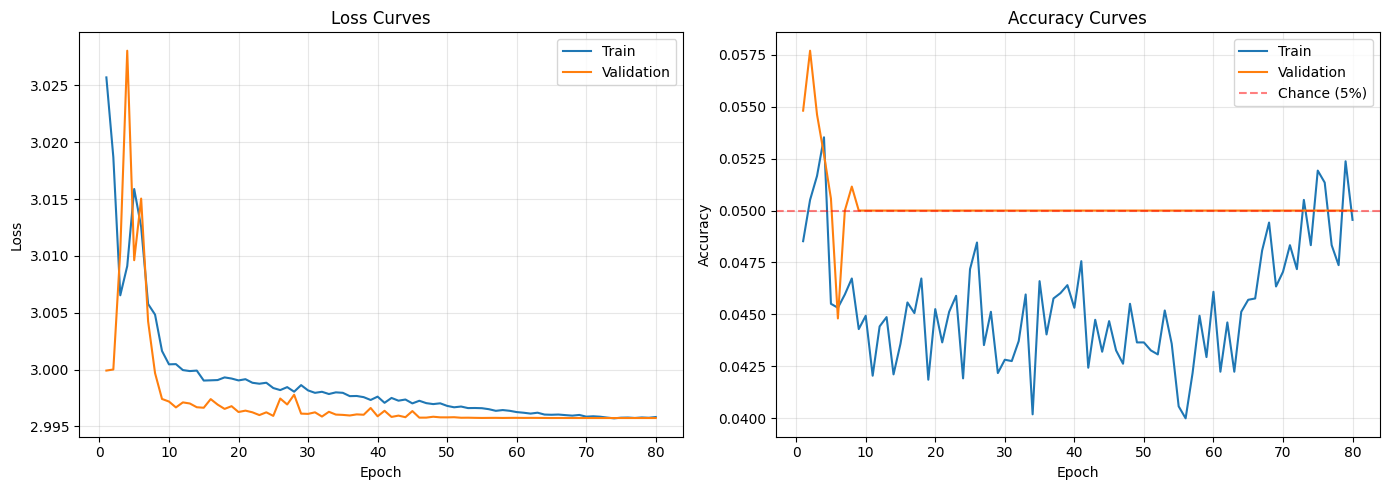

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train')
ax1.plot(epochs_range, history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train')
ax2.plot(epochs_range, history['val_acc'], label='Validation')
ax2.axhline(y=0.05, color='r', linestyle='--', alpha=0.5, label='Chance (5%)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'cnn_transformer_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Test Set Evaluation

In [30]:
# Load best model
ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'cnn_transformer_best.pt'), map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f}, val_acc={ckpt['val_acc']:.4f})")

test_loss, test_acc, test_preds, test_labels, test_subs = evaluate(
    model, test_loader, criterion, device
)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")

Loaded best model from epoch 71 (val_loss=2.9957, val_acc=0.0500)


/var/tmp/ipykernel_36192/2820293787.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(CHECKPOINT_PATH, 'cnn_transformer_best.pt'), map_locat


Test Loss: 2.9957
Test Accuracy: 0.0500 (5.00%)
Chance level: 5.00%


### Per-Subject Accuracy

In [31]:
subject_correct = {}
subject_total = {}
for pred, label, sub in zip(test_preds, test_labels, test_subs):
    sub = str(sub)
    if sub not in subject_correct:
        subject_correct[sub] = 0
        subject_total[sub] = 0
    subject_total[sub] += 1
    if pred.item() == label.item():
        subject_correct[sub] += 1

print(f"{'Subject':<10} {'Accuracy':>10} {'Correct':>10} {'Total':>8}")
print("-" * 40)
for sub in sorted(subject_correct.keys()):
    acc = subject_correct[sub] / subject_total[sub]
    print(f"{sub:<10} {acc:>10.4f} {subject_correct[sub]:>10} {subject_total[sub]:>8}")
print("\nNote: sub-03, sub-19, sub-20 are known to be noisier.")

Subject      Accuracy    Correct    Total
----------------------------------------
sub-02         0.0500         20      400
sub-03         0.0500         20      400
sub-05         0.0500         20      400
sub-09         0.0500         20      400
sub-14         0.0500         20      400
sub-15         0.0500         20      400
sub-17         0.0500         20      400
sub-19         0.0500         20      400
sub-20         0.0500         20      400
sub-23         0.0500         20      400
sub-24         0.0500         20      400
sub-28         0.0500         20      400
sub-29         0.0500         20      400

Note: sub-03, sub-19, sub-20 are known to be noisier.


### Confusion Matrix & Most Confused Pairs

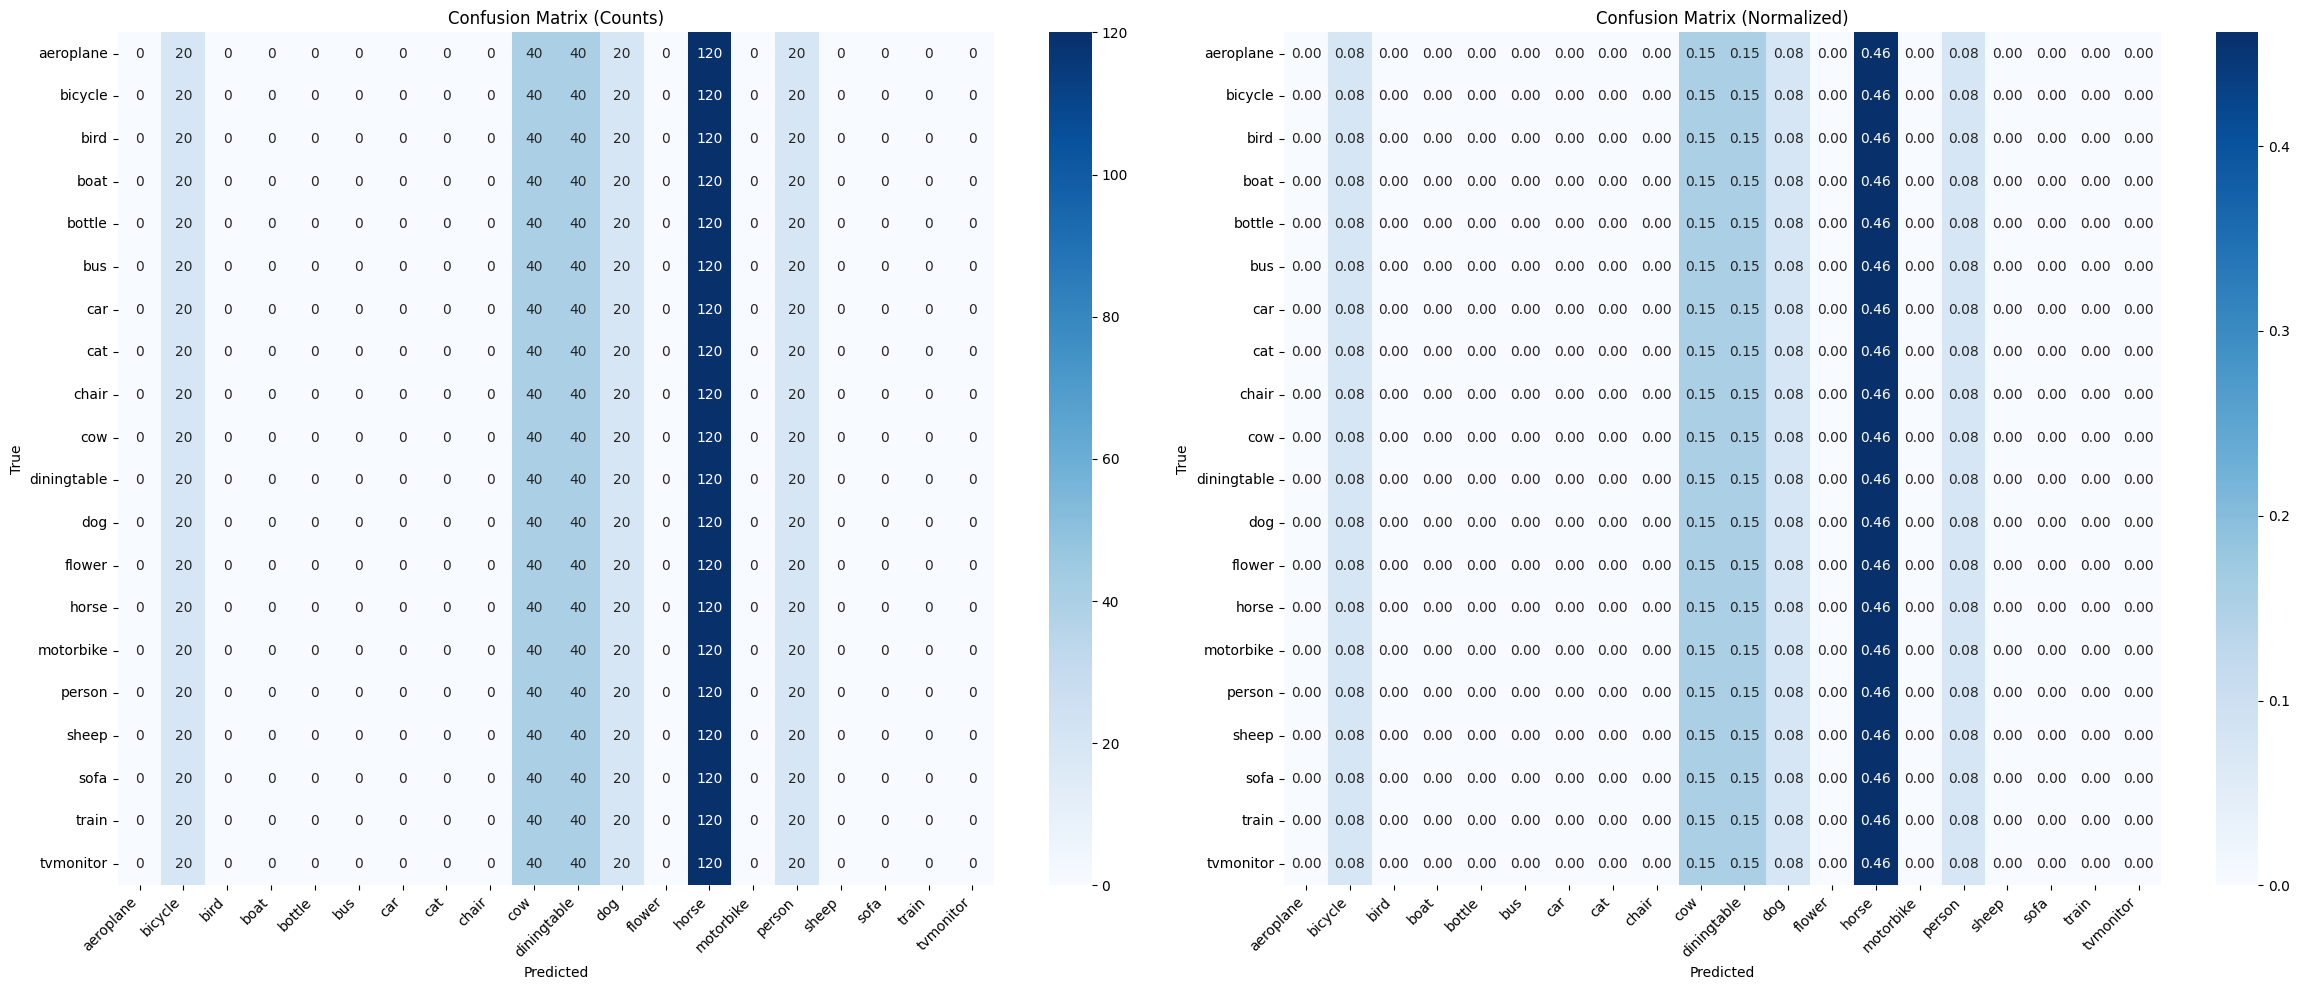


Top 15 Most Confused Pairs (True -> Predicted : Count)
-------------------------------------------------------
  aeroplane       -> horse           : 120
  bicycle         -> horse           : 120
  bird            -> horse           : 120
  boat            -> horse           : 120
  bottle          -> horse           : 120
  bus             -> horse           : 120
  car             -> horse           : 120
  cat             -> horse           : 120
  chair           -> horse           : 120
  cow             -> horse           : 120
  diningtable     -> horse           : 120
  dog             -> horse           : 120
  flower          -> horse           : 120
  motorbike       -> horse           : 120
  person          -> horse           : 120


In [32]:
from sklearn.metrics import confusion_matrix

idx_to_cat = mappings['idx_to_cat']
category_names = [idx_to_cat[i] for i in range(20)]

cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), labels=range(20))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=category_names, yticklabels=category_names)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')
ax1.set_title('Confusion Matrix (Counts)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            xticklabels=category_names, yticklabels=category_names)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title('Confusion Matrix (Normalized)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, 'cnn_transformer_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
confused_pairs = []
for i in range(20):
    for j in range(20):
        if i != j:
            confused_pairs.append((category_names[i], category_names[j], cm[i, j]))
confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 15 Most Confused Pairs (True -> Predicted : Count)")
print("-" * 55)
for true_cat, pred_cat, count in confused_pairs[:15]:
    print(f"  {true_cat:<15} -> {pred_cat:<15} : {count}")

## 7. Kaggle Submission & Summary

In [33]:
submission = pd.DataFrame({
    'Id': range(len(test_preds)),
    'Category': test_preds.numpy(),
})
submission_path = os.path.join(PROJECT_DIR, 'submission_cnn_transformer.csv')
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")

print("\n" + "=" * 60)
print("CNN + TRANSFORMER + SUBJECT HEADS SUMMARY")
print("=" * 60)
print(f"Architecture: TemporalCNN(500->128x4) + Proj(512->128)")
print(f"  + Transformer(4 layers, 8 heads, ff=512)")
print(f"  + Shared Head + 13 Subject Residual Heads")
print(f"Parameters: {total_params:,}")
print(f"Best epoch: {ckpt['epoch']}")
print(f"Best val loss: {ckpt['val_loss']:.4f}")
print(f"Best val acc: {ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")
print(f"Test acc: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Chance level: 5.00%")
print(f"Checkpoint: {os.path.join(CHECKPOINT_PATH, 'cnn_transformer_best.pt')}")
print("=" * 60)

Submission saved to /jet/home/sharmar/eeg-project/submission_cnn_transformer.csv

CNN + TRANSFORMER + SUBJECT HEADS SUMMARY
Architecture: TemporalCNN(500->128x4) + Proj(512->128)
  + Transformer(4 layers, 8 heads, ff=512)
  + Shared Head + 13 Subject Residual Heads
Parameters: 1,252,504
Best epoch: 71
Best val loss: 2.9957
Best val acc: 0.0500 (5.00%)
Test acc: 0.0500 (5.00%)
Chance level: 5.00%
Checkpoint: /jet/home/sharmar/eeg-project/checkpoints/cnn_transformer_best.pt
